In [2]:
import numpy as np
import json
import os

In [73]:
file = "/common/users/dm1487/namo_data/Mar29/sequence_1_20250329_074437_westeros.cs.rutgers.edu_0.json"

with open(file, 'r') as f:
    data = json.load(f)

obj = data['data_points'][0]['action']['object_name']
print("Selected object: ", obj)
print("current state: ", data['data_points'][0]['state']['objects'][obj])
print("goal state: ", data['data_points'][0]['action']['goal_state'])


Selected object:  obstacle_13_movable
current state:  {'position': [-2.2509376304947555, -2.3369760287387527, 0.2995048460074568], 'quaternion': [0.9153254873838427, 1.4691869907622116e-18, -6.463967516764617e-19, 0.4027148521541401]}
goal state:  {'position': [-1.9212367228054437, -1.8605526365857963, 0.0], 'quaternion': [0.858913445888733, 0.0, 0.0, 0.5121207791835267]}


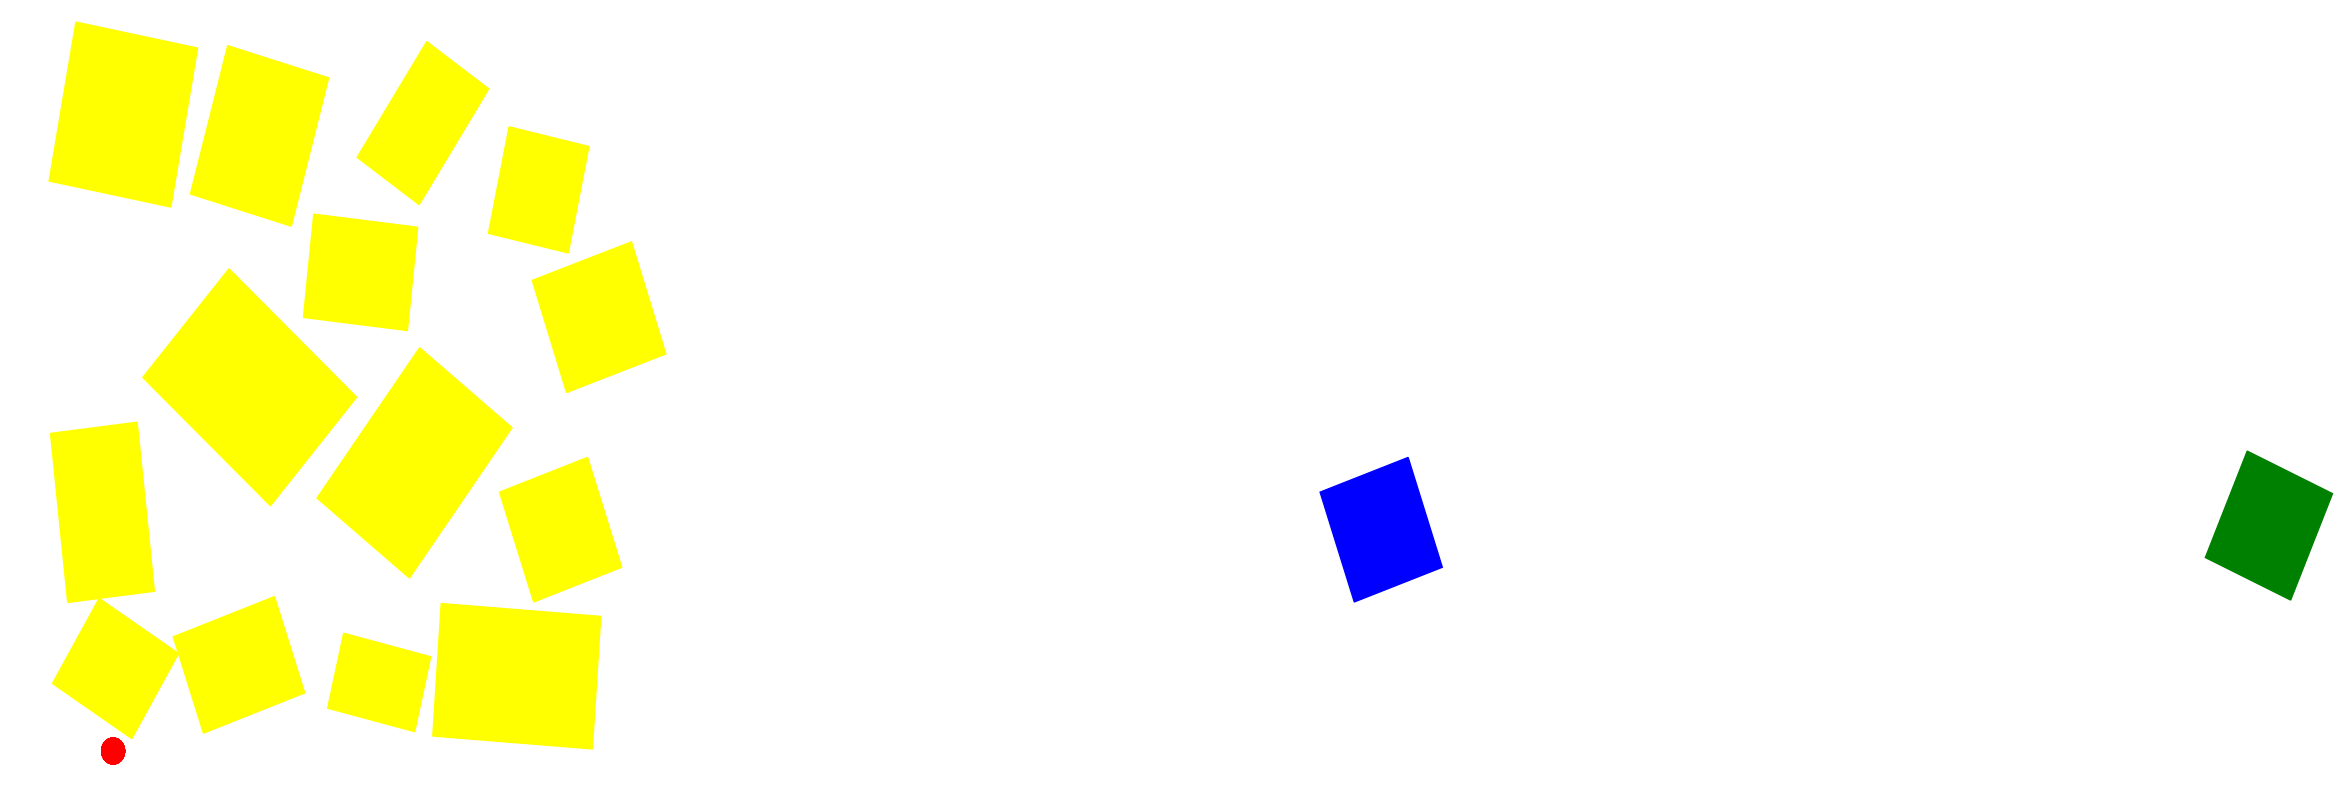

In [78]:
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle, Circle
from scipy.spatial.transform import Rotation as R


def load_object_sizes(env_config_name):
    filename = f"namo_objects_{env_config_name}.txt"
    import csv
    object_sizes = {}
    with open(filename, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            name = row["object_name"]
            size_x = float(row["size_x"])
            size_y = float(row["size_y"])
            object_sizes[name] = (size_x, size_y)
    return object_sizes

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
for ax in axes:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.axis('off')
    
ax = axes.flatten()
    
object_sizes = load_object_sizes("env_config_1")
pt = data['data_points'][2]
goal_obj = pt['action']['object_name']
for obj_name, obj_data in pt['state']['objects'].items():
    robot_size = 0.1
    robot_rect = Circle((pt['state']['robot']['position'][0] - robot_size / 2, pt['state']['robot']['position'][1] - robot_size / 2), robot_size, fill=True, color='red')
    ax[0].add_patch(robot_rect)
    
    size_x, size_y = object_sizes[obj_name]
    size_x *= 2
    size_y *= 2
    color = 'yellow'
    if obj_name == goal_obj:
        color = 'blue'
        rot = R.from_quat([pt['action']['goal_state']['quaternion'][0], pt['action']['goal_state']['quaternion'][1], pt['action']['goal_state']['quaternion'][2], pt['action']['goal_state']['quaternion'][3]], scalar_first=True).as_euler('xyz', degrees=True)
        goal_rect = Rectangle((pt['action']['goal_state']['position'][0] - size_x / 2, pt['action']['goal_state']['position'][1] - size_y / 2), size_x, size_y, angle=rot[2], rotation_point='center', fill=True, color='green')
        ax[2].add_patch(goal_rect)
        
    rotation = R.from_quat([obj_data['quaternion'][0], obj_data['quaternion'][1], obj_data['quaternion'][2], obj_data['quaternion'][3]], scalar_first=True).as_euler('xyz', degrees=True)
    if color == 'blue':
        ax[1].add_patch(Rectangle((obj_data['position'][0] - size_x / 2, obj_data['position'][1] - size_y / 2), size_x, size_y, angle=rotation[2], rotation_point='center', fill=True, color=color))
    ax[0].add_patch(Rectangle((obj_data['position'][0] - size_x / 2, obj_data['position'][1] - size_y / 2), size_x, size_y, angle=rotation[2], rotation_point='center', fill=True, color='yellow'))

dict_keys(['action', 'state', 'step_idx'])
Processed 0 scenes...
dict_keys(['action', 'state', 'step_idx'])
Processed 1 scenes...
dict_keys(['action', 'state', 'step_idx'])
Processed 2 scenes...
dict_keys(['state'])
Processed 3 scenes...


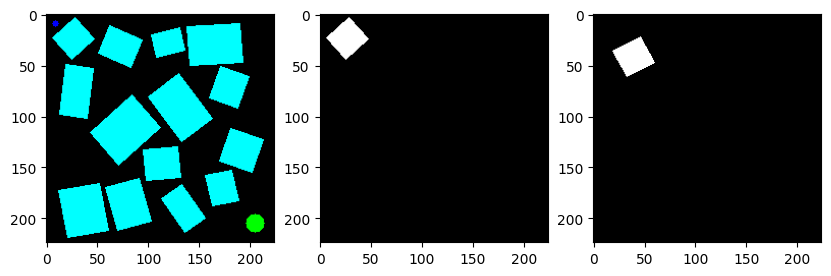

In [180]:
from PIL import Image
image = np.load('dataset_images/scene_0.npz')
fig, ax = plt.subplots(1, 3, figsize=(10, 10))
ax[0].imshow(image['scene'])
ax[1].imshow(image['object_mask'], cmap='gray')
ax[2].imshow(image['goal_mask'], cmap='gray')
plt.show()

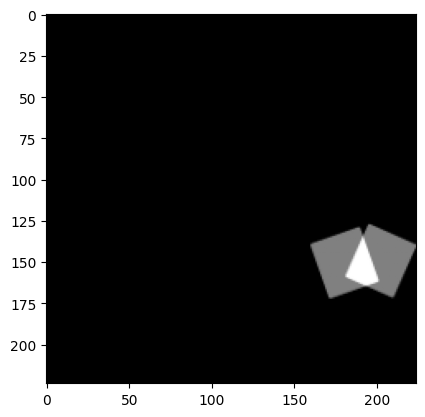

In [303]:
import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R

def create_scene_images(data_point, object_sizes, save_dir, index):
    IMG_SIZE = 224
    WORLD_SIZE = 6.0  # -3 to 3
    scale = IMG_SIZE / WORLD_SIZE  # pixels per world unit
    
    def world_to_pixel(x, y):
        # Convert world coordinates (-3 to 3) to pixel coordinates (0 to 224)
        px = int((x + WORLD_SIZE/2) * scale)
        py = int((y + WORLD_SIZE/2) * scale)
        return px, py
    
    def draw_rotated_rectangle(img, center, size, angle, color):
        # Convert world coordinates to pixel coordinates
        center_px = world_to_pixel(center[0], center[1])
        size_px = (int(size[0] * scale), int(size[1] * scale))
        
        # Create rotation matrix
        rect = ((center_px[0], center_px[1]), size_px, angle)
        box = cv2.boxPoints(rect)
        box = np.int32(box)
        
        # Draw filled polygon
        cv2.fillPoly(img, [box], color)
        return img
    
    def draw_circle(img, center, radius, color):
        center_px = world_to_pixel(center[0], center[1])
        radius_px = int(radius * scale)
        cv2.circle(img, center_px, radius_px, color, -1)  # -1 means filled
        return img
    
    # 1. Create scene image (RGB)
    scene_image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    
    # Draw robot (red circle)
    robot_pos = data_point['state']['robot']['position']
    robot_size = 0.1
    draw_circle(scene_image, 
               (robot_pos[0], robot_pos[1]),
               robot_size,
               (255, 0, 0))  # BGR format
    
    # Draw goal indicator (green circle)
    draw_circle(scene_image,
               (2.5, 2.5),
               0.25,
               (0, 255, 0))
    
    # Draw objects (yellow rectangles)
    for obj_name, obj_data in data_point['state']['objects'].items():
        size_x, size_y = object_sizes[obj_name]
        size_x *= 2
        size_y *= 2
        
        rotation = R.from_quat(obj_data['quaternion'], scalar_first=True).as_euler('xyz', degrees=True)[2]
        draw_rotated_rectangle(scene_image,
                             (obj_data['position'][0], obj_data['position'][1]),
                             (size_x, size_y),
                             rotation,
                             (0, 0, 255))  # BGR yellow
    
    # 2 & 3. Create masks
    object_mask = np.zeros((IMG_SIZE, IMG_SIZE, 1), dtype=np.uint8)
    goal_mask = np.zeros((IMG_SIZE, IMG_SIZE, 1), dtype=np.uint8)
    
    if 'action' in data_point:
        # Object mask
        goal_obj = data_point['action']['object_name']
        obj_data = data_point['state']['objects'][goal_obj]
        size_x, size_y = object_sizes[goal_obj]
        size_x *= 2
        size_y *= 2
        
        rotation = R.from_quat(obj_data['quaternion'], scalar_first=True).as_euler('xyz', degrees=True)[2]
        draw_rotated_rectangle(object_mask,
                             (obj_data['position'][0], obj_data['position'][1]),
                             (size_x, size_y),
                             rotation,
                             255)
        
        # Goal mask
        goal_state = data_point['action']['goal_state']
        rotation = R.from_quat(goal_state['quaternion'], scalar_first=True).as_euler('xyz', degrees=True)[2]
        draw_rotated_rectangle(goal_mask,
                             (goal_state['position'][0], goal_state['position'][1]),
                             (size_x, size_y),
                             rotation,
                             255)
    
    # Normalize to [0, 1] range
    scene_image = scene_image.astype(np.float32) / 255.0
    object_mask = object_mask.astype(np.float32) / 255.0
    goal_mask = goal_mask.astype(np.float32) / 255.0
    
    # Save arrays
    np.savez(os.path.join(save_dir, f'scene_{index}.npz'),
             scene=scene_image,
             object_mask=object_mask,
             goal_mask=goal_mask)

# Usage remains the same
def create_dataset(data_file, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    object_sizes = load_object_sizes("env_config_1")
    
    with open(data_file, 'r') as f:
        data = json.load(f)
    
    for i, data_point in enumerate(data['data_points']):
        create_scene_images(data_point, object_sizes, save_dir, i)
        if i % 1 == 0:
            print(f"Processed {i} scenes...")

In [229]:
# Usage
data_file = "/common/users/dm1487/namo_data/Mar29/sequence_1_20250329_074437_westeros.cs.rutgers.edu_0.json"
save_dir = "dataset_images"
create_dataset(data_file, save_dir)

Processed 0 scenes...
Processed 1 scenes...
Processed 2 scenes...
Processed 3 scenes...


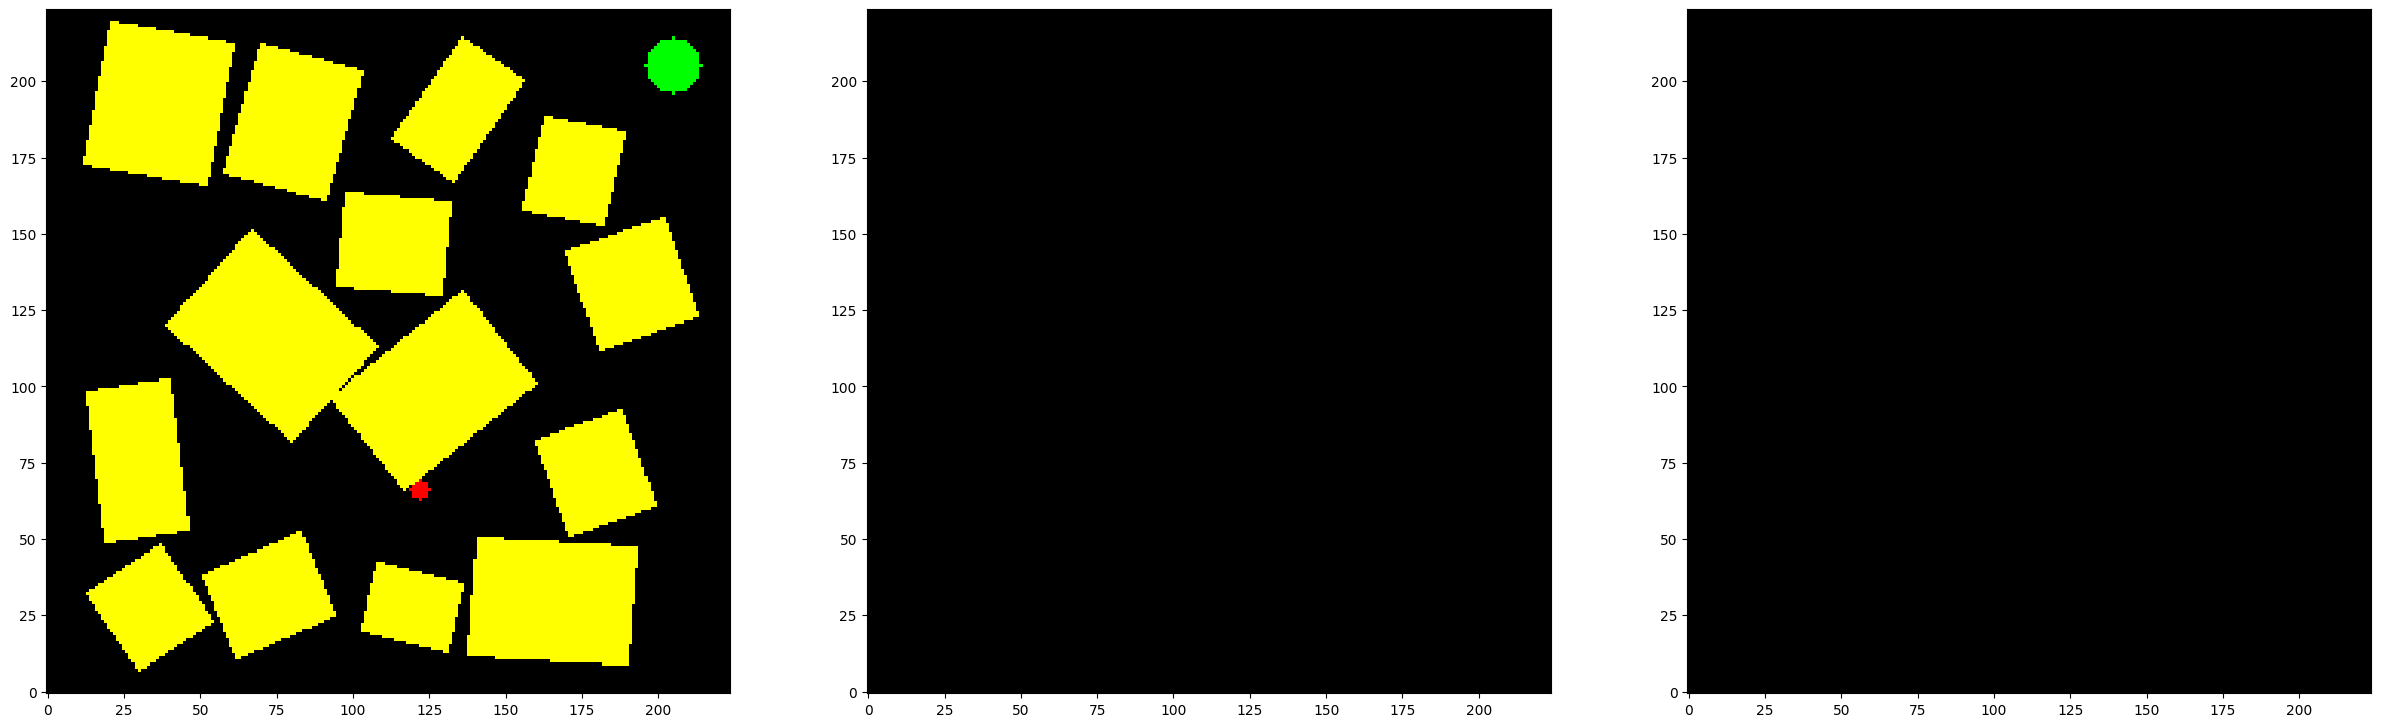

In [7]:
from PIL import Image
from matplotlib import pyplot as plt
image = np.load('/common/users/dm1487/namo_data/env_config_1_tr_images/sequence_20250329_160049_4619b3_env_config_1_iter99_20250329_160158_ilab2.cs.rutgers.edu_1_dp000002.npz')

fig, ax = plt.subplots(1, 3, figsize=(30, 10))
ax[0].imshow(image['scene'][:, :, :])
ax[0].invert_yaxis()
ax[1].imshow(image['object_mask'], cmap='gray')
ax[1].invert_yaxis()
ax[2].imshow(image['goal_mask'], cmap='gray')
ax[2].invert_yaxis()
plt.show()

In [3]:
len(os.listdir('/common/users/dm1487/namo_data/env_config_1_tr_images'))

3882

In [3]:
import os
folder_path = "/common/users/dm1487/namo_data/env_config_1_tr"
files = [f for f in os.listdir(folder_path) if (f.endswith('.npz') and not f.endswith('00.npz'))]
len(files)


FileNotFoundError: [Errno 2] No such file or directory: '/common/users/dm1487/namo_data/env_config_1_tr'